# EF1A / Sec61b ER Reporter Quantification

Single-channel (488) z-stack quantification of an ER-localized reporter
(Sec61b-GFP) driven by two EF1A promoter lengths (2.2kb vs 2.6kb) at landing site 14a.

**Part 1 - Setup**: imports, paths, background model (swappable for calibration).
**Part 2 - Process constructs**: background-subtract -> MIP -> per-fish metrics.
**Part 3 - Compare constructs**: summary table, figures, sample montage.

Primary metric: `mip_mean` (whole-field mean of the background-subtracted MIP).
Single channel, no internal control - comparisons assume consistent imaging.

## Part 1 - Setup

In [1]:
# Install required packages (run once)
!pip install nd2 numpy matplotlib pandas scipy scikit-image

In [2]:
import os
from pathlib import Path

import numpy as np
import nd2
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from skimage.filters import threshold_otsu

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['image.cmap'] = 'gray'

PROJECT_DIR = Path(os.environ.get('ZEBRAFISH_PROJECT_DIR') or Path.cwd())
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
RAW_DATA_DIR = Path(os.environ.get('ZEBRAFISH_RAW_DATA_DIR') or (PROJECT_DIR / 'raw_data'))
FIGURES_DIR = PROJECT_DIR / 'figures'
MEASUREMENTS_DIR = PROJECT_DIR / 'measurements'
FIGURES_DIR.mkdir(exist_ok=True)
MEASUREMENTS_DIR.mkdir(exist_ok=True)

PIXEL_UM = 0.8   # XY pixel size (um)

# --- Background model -----------------------------------------------------
# INTERIM: no calibration frames yet, so estimate background per image as a low
# percentile of the stack. When 488 laser-off/on calibration is collected, set
# CALIBRATION_488 below to switch to a dark/light model (as in the other projects).
BACKGROUND_PERCENTILE = 5
CALIBRATION_488 = {'off': RAW_DATA_DIR / 'bglaser' / '488-off001.nd2',
                   'on':  RAW_DATA_DIR / 'bglaser' / '488-on001.nd2'}

CALIB_BG = None
if CALIBRATION_488:
    with nd2.ND2File(CALIBRATION_488['on']) as f:
        CALIB_BG = np.squeeze(f.asarray()).astype(np.float64).mean(axis=0)  # (Y, X)
    print('Using calibration background (mean of laser-on frames).')
else:
    print(f'Interim background: per-image {BACKGROUND_PERCENTILE}th percentile.')


def load_stack(filepath):
    """Load a single-channel ND2 as (Z, Y, X) float64."""
    with nd2.ND2File(filepath) as f:
        a = np.squeeze(f.asarray()).astype(np.float64)
    if a.ndim == 2:
        a = a[np.newaxis]
    return a


def subtract_bg(stack):
    """Background-subtract a stack and clip at zero."""
    if CALIB_BG is not None:
        return np.clip(stack - CALIB_BG[np.newaxis], 0, None)
    return np.clip(stack - np.percentile(stack, BACKGROUND_PERCENTILE), 0, None)


print('Setup complete.')
print(f'  Project: {PROJECT_DIR}')
print(f'  Raw data: {RAW_DATA_DIR}  (exists: {RAW_DATA_DIR.exists()})')

Using calibration background (mean of laser-on frames).
Setup complete.
  Project: <repo>
  Raw data: <repo>/raw_data  (exists: True)


## Part 2 - Process constructs

In [3]:
# Per-fish processing and a reusable per-construct runner.
import re

def _fish_num(filename, index):
    """Fish id from the TRAILING number in the filename (falls back to position).
    Uses the last number, not the first: names like 'p14a_sec61b_..._001' would
    otherwise all collapse to '14' (from the 'p14a' prefix)."""
    nums = re.findall(r'(\d+)', Path(filename).stem)
    return nums[-1] if nums else f'{index:03d}'


def process_fish(filepath):
    """Background-subtract one 488 z-stack and measure it. The fish is the unit.
    Primary metric is projection-independent; MIP metrics kept for robustness.
    - stack_mean : mean over ALL voxels of the bg-subtracted stack (PRIMARY).
                   Linear (= sum / n_z), projection-independent, z-count-safe.
    - mip_mean/signal_mean/coverage/total/cv: MIP readouts, kept for comparison.
    """
    stack = load_stack(filepath)
    sub = subtract_bg(stack)                      # (Z, Y, X), bg-subtracted, >= 0
    mip = sub.max(axis=0)

    try:
        thr = threshold_otsu(mip)
    except Exception:
        thr = float(mip.mean())
    sig = mip > thr                              # 2D MIP mask (legacy)

    row = {
        'stack_mean': float(sub.mean()),                                  # PRIMARY (mean-over-stack)
        'mip_mean': float(mip.mean()),                                    # robustness (former primary)
        'signal_mean': float(mip[sig].mean()) if sig.any() else 0.0,      # MIP ER-positive mean
        'coverage': float(sig.mean()),                                    # MIP ER area fraction
        'total': float(mip.sum()),                                        # legacy integrated (MIP)
        'cv': float(mip.std() / mip.mean()) if mip.mean() else float('nan'),
        'n_slices': int(stack.shape[0]),
    }
    return row, mip


import fnmatch

RESULTS = {}   # construct name -> {'df' (per-fish), 'fov_df', 'mips', 'dir'}

# The FISH is the independence unit, NOT the field of view. Some fish were imaged
# at several FOVs; treating those FOVs as replicates is pseudoreplication and
# fakes significance. process_construct measures every FOV, then collapses the
# FOVs of one fish into a single per-fish mean before any stats/plots.
FISH_METRICS = ['stack_mean', 'mip_mean', 'signal_mean', 'coverage', 'total', 'cv']

# Primary quantification: mean-over-stack (linear, projection-independent, and
# insensitive to the number of z-planes). MIP mean and the 3D ER-mask mean are
# reported as cross-checks (see the robustness cell).
PRIMARY = 'stack_mean'
PRIMARY_LABEL = 'mean-over-stack (A.U.)'


def _assign_fish(files, fov_groups):
    """Map each file -> fish id. `fov_groups` is a list of
    {'pattern': <glob>, 'fovs_per_fish': k}: files matching the pattern are taken
    in sorted order and grouped in consecutive runs of k into one fish.
    Files matching no pattern are one fish each (1 FOV)."""
    assign, matched = {}, set()
    for gi, g in enumerate(fov_groups or []):
        grp = sorted(f for f in files if fnmatch.fnmatch(f.name, g['pattern']))
        k = int(g.get('fovs_per_fish', 1))
        for r, f in enumerate(grp):
            assign[f] = f'g{gi + 1}_fish{r // k + 1:02d}'
            matched.add(f)
    for i, f in enumerate(files):
        if f not in matched:
            assign[f] = f'fish{i + 1:02d}'
    return assign


def process_construct(folder, name, pattern='*.nd2', fov_groups=None):
    """Measure every FOV, then collapse FOVs of the same fish to a per-fish mean."""
    data_dir = RAW_DATA_DIR / folder
    files = sorted(data_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files in {data_dir}')
    fish_of = _assign_fish(files, fov_groups)

    fov_rows, fov_mips = [], {}
    for fp in files:
        row, mip = process_fish(fp)
        fov_rows.append({'construct': name, 'fish': fish_of[fp], 'filename': fp.name, **row})
        fov_mips[fp.name] = mip
    fov_df = pd.DataFrame(fov_rows)

    # collapse FOVs -> one row per fish
    df = fov_df.groupby('fish', as_index=False)[FISH_METRICS].mean()
    df.insert(0, 'construct', name)
    df['n_fov'] = fov_df.groupby('fish')['filename'].size().values

    # representative image per fish = the FOV closest to that fish's own mean
    mips = {}
    for fish, sub in fov_df.groupby('fish'):
        best = sub.iloc[(sub[PRIMARY] - sub[PRIMARY].mean()).abs().argmin()]['filename']
        mips[fish] = fov_mips[best]

    fov_df.to_csv(MEASUREMENTS_DIR / f'measurements_{name}_fov.csv', index=False)
    out = MEASUREMENTS_DIR / f'measurements_{name}.csv'
    df.to_csv(out, index=False)
    RESULTS[name] = {'df': df, 'fov_df': fov_df, 'mips': mips, 'dir': data_dir}
    print(f'{name}: {len(files)} FOV -> {len(df)} fish; '
          f"{PRIMARY} = {df[PRIMARY].mean():.1f} +/- {df[PRIMARY].std():.1f} (n={len(df)} fish); saved {out.name}")
    return df

def show_construct(name, n_samples=4):
    df = RESULTS[name]['df']
    mips = RESULTS[name]['mips']
    order = df.sort_values(PRIMARY)['fish'].tolist()
    idx = np.linspace(0, len(order) - 1, min(n_samples, len(order)))
    picks = [order[int(round(k))] for k in idx]
    vmax = np.percentile(np.concatenate([mips[f].ravel() for f in picks]), 99.5)
    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4))
    for ax, f in zip(np.atleast_1d(axes), picks):
        ax.imshow(mips[f], vmin=0, vmax=vmax)
        ax.set_title(f'fish {f}  (mean {mips[f].mean():.0f})', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'{name}: sample MIPs (low -> high)', fontweight='bold')
    plt.tight_layout(); plt.show()

In [4]:
# ----- Constructs to process (2.2kb vs 2.6kb promoter) -----
# Every fish = one ND2 = one FOV, imaged in the same anatomical region at the same
# hpf (the fish is the independence unit). 'pattern' selects the files in a folder
# that belong to the current, uniformly-collected dataset. ('fov_groups' remains
# available in process_construct for any future multi-FOV batch.)
CONSTRUCTS = [
    # 2.2 kb: 12 original (14a_ef1a_sec61b-*) + 5 male2, 1 FOV each -> n=17.
    {'folder': '14aef1a_sec61b',       'name': '14a-ef1a'},
    # 2.6 kb: the large uniform single-FOV batch only (f1) -> n=30. The earlier
    # 3-FOV batch and the male1 fish are intentionally excluded.
    {'folder': '14aef1a_extra_sec61b', 'name': '14a-ef1a-extra',
     'pattern': 'p14aSec61b_ef1aExtra_f1_*.nd2'},
]
# -------------------------------------------------
for cfg in CONSTRUCTS:
    process_construct(cfg['folder'], cfg['name'],
                      pattern=cfg.get('pattern', '*.nd2'),
                      fov_groups=cfg.get('fov_groups'))

14a-ef1a: 17 FOV -> 17 fish; stack_mean = 482.1 +/- 49.4 (n=17 fish); saved measurements_14a-ef1a.csv


14a-ef1a-extra: 30 FOV -> 30 fish; stack_mean = 463.5 +/- 37.0 (n=30 fish); saved measurements_14a-ef1a-extra.csv


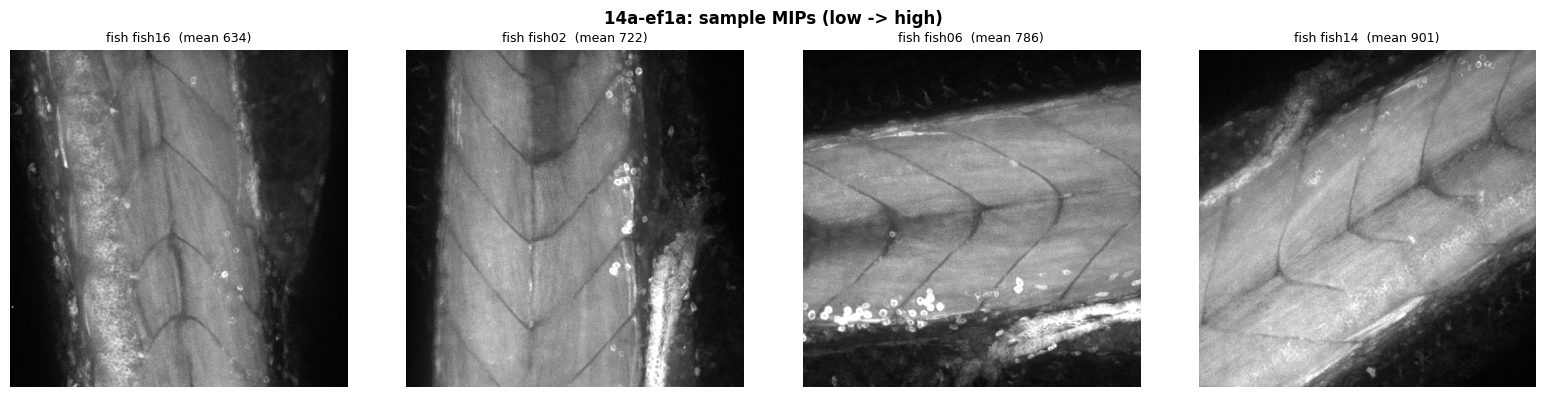

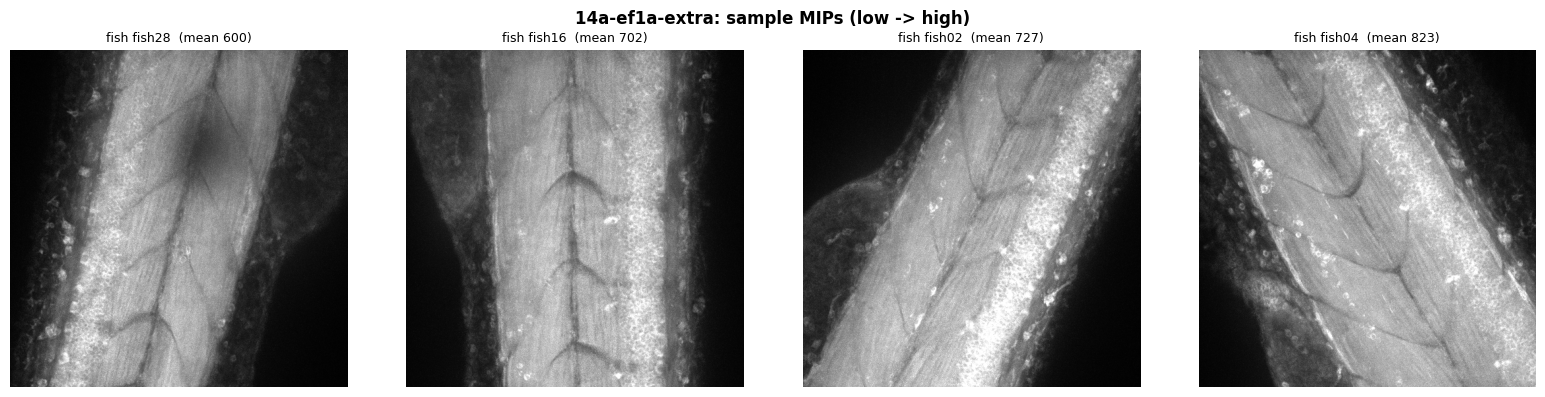

In [5]:
for cfg in CONSTRUCTS:
    show_construct(cfg['name'])

## Part 3 - Compare constructs

In [6]:
names = [c['name'] for c in CONSTRUCTS]
combined = pd.concat([RESULTS[n]['df'] for n in names], ignore_index=True)
summary = (combined.groupby('construct')
           .agg(n=(PRIMARY, 'size'),
                stack_mean=('stack_mean', 'mean'), stack_sd=('stack_mean', 'std'),
                mip_mean=('mip_mean', 'mean'),
                signal_mean=('signal_mean', 'mean'),
                cv=('cv', 'mean'))
           .loc[names].round(2))
print(summary)

# Stats on the primary metric (mean-over-stack); the fish is the unit.
groups = {n: RESULTS[n]['df'][PRIMARY].values for n in names}
if len(names) == 2:
    a, b = groups.values()
    u, p = stats.mannwhitneyu(a, b)
    print(f"\n{PRIMARY_LABEL} -- Mann-Whitney {names[0]} vs {names[1]}: "
          f"p={p:.3e}; fold={b.mean()/a.mean():.2f}x")
elif len(names) > 2:
    h, p = stats.kruskal(*groups.values())
    print(f"\n{PRIMARY_LABEL} -- Kruskal-Wallis across {len(names)} constructs: H={h:.2f}, p={p:.2e}")
    ks = list(groups); m = len(ks) * (len(ks) - 1) // 2
    for i in range(len(ks)):
        for j in range(i + 1, len(ks)):
            _, pp = stats.mannwhitneyu(groups[ks[i]], groups[ks[j]])
            print(f"  {ks[i]} vs {ks[j]}: p={pp:.2e} (corrected {min(pp*m,1):.2e})")

                 n  stack_mean  stack_sd  mip_mean  signal_mean    cv
construct                                                            
14a-ef1a        17      482.14     49.37    747.51      1082.84  0.63
14a-ef1a-extra  30      463.50     37.01    715.12      1054.65  0.64

mean-over-stack (A.U.) -- Mann-Whitney 14a-ef1a vs 14a-ef1a-extra: p=2.635e-01; fold=0.96x


In [7]:
# Robustness cross-check: does the promoter difference survive the choice of
# projection? Primary (mean-over-stack, projection-independent) vs the legacy MIP
# mean. The fish is the independence unit.
if len(names) == 2:
    checks = [('stack_mean', 'mean-over-stack (PRIMARY)'),
              ('mip_mean', 'MIP mean (legacy)')]
    an, bn = names
    na, nb_ = len(RESULTS[an]['df']), len(RESULTS[bn]['df'])
    print(f'{an} (n={na}) vs {bn} (n={nb_}) fish\n')
    print(f'{"metric":28s} {an[:10]:>10s} {bn[:10]:>10s} {"fold":>6s} {"p(MW)":>7s} {"d":>6s}')
    for key, lab in checks:
        a = RESULTS[an]['df'][key].values
        b = RESULTS[bn]['df'][key].values
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        d = (b.mean() - a.mean()) / np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
        print(f'{lab:28s} {a.mean():10.1f} {b.mean():10.1f} {b.mean()/a.mean():6.2f} {p:7.3f} {d:6.2f}')
    print('\nSame direction + significance from the projection-independent metric = not a MIP artifact.')

14a-ef1a (n=17) vs 14a-ef1a-extra (n=30) fish

metric                         14a-ef1a 14a-ef1a-e   fold   p(MW)      d
mean-over-stack (PRIMARY)         482.1      463.5   0.96   0.264  -0.43
MIP mean (legacy)                 747.5      715.1   0.96   0.245  -0.48

Same direction + significance from the projection-independent metric = not a MIP artifact.


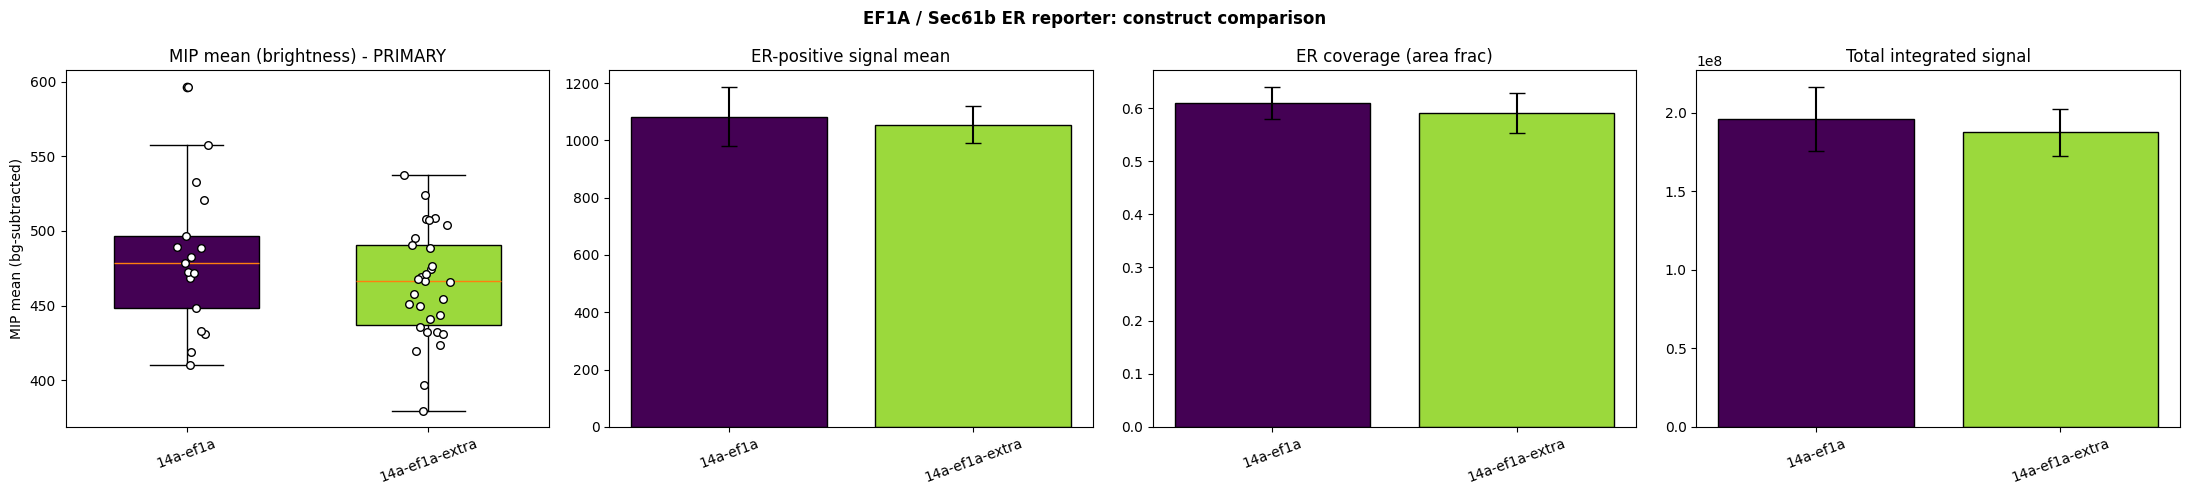

In [8]:
# Comparison figure: primary (MIP mean) + secondary metrics.
pal = plt.cm.viridis(np.linspace(0, 0.85, len(names)))
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

data = [groups[n] for n in names]
bp = axes[0].boxplot(data, tick_labels=names, widths=0.6, patch_artist=True)
for p, c in zip(bp['boxes'], pal):
    p.set_facecolor(c)
np.random.seed(0)
for i, g in enumerate(data):
    axes[0].scatter(np.random.normal(i + 1, 0.04, len(g)), g, color='white', edgecolor='black', s=30, zorder=3)
axes[0].set(title='MIP mean (brightness) - PRIMARY', ylabel='MIP mean (bg-subtracted)')
axes[0].tick_params(axis='x', rotation=20)

for ax, col, title in [(axes[1], 'signal_mean', 'ER-positive signal mean'),
                       (axes[2], 'coverage', 'ER coverage (area frac)'),
                       (axes[3], 'total', 'Total integrated signal')]:
    means = [RESULTS[n]['df'][col].mean() for n in names]
    sds = [RESULTS[n]['df'][col].std() for n in names]
    ax.bar(names, means, yerr=sds, capsize=6, color=pal, edgecolor='black')
    ax.set(title=title); ax.tick_params(axis='x', rotation=20)

plt.suptitle('EF1A / Sec61b ER reporter: construct comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'construct_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

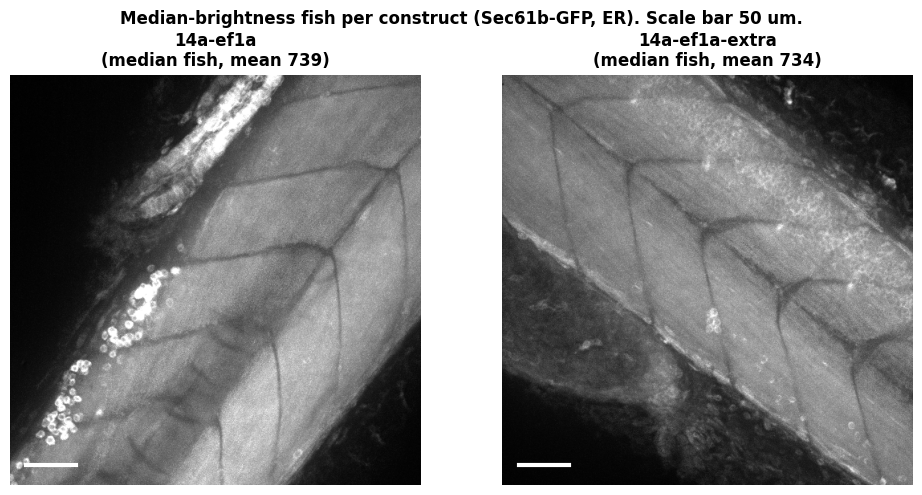

In [9]:
# Representative (median-brightness) fish per construct, shared scale + scale bar.
reps = {}
for n in names:
    df = RESULTS[n]['df'].sort_values(PRIMARY)
    f = df.iloc[len(df) // 2]['fish']
    reps[n] = RESULTS[n]['mips'][f]
vmax = np.percentile(np.concatenate([m.ravel() for m in reps.values()]), 99.5)
sb_px = int(50 / PIXEL_UM)   # 50 um scale bar
fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 5))
for ax, n in zip(np.atleast_1d(axes), names):
    m = reps[n]
    ax.imshow(m, vmin=0, vmax=vmax)
    ax.set_title(f'{n}\n(median fish, mean {m.mean():.0f})', fontweight='bold')
    ax.plot([20, 20 + sb_px], [m.shape[0] - 25] * 2, 'w-', lw=3)
    ax.axis('off')
plt.suptitle('Median-brightness fish per construct (Sec61b-GFP, ER). Scale bar 50 um.', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'construct_montage.png', dpi=200, bbox_inches='tight')
plt.show()

## Part 4 - Publication figure

Two grayscale panels (representative median-brightness fish) labeled by promoter
length, plus a violin of MIP mean. Construct = `p14a.eef1a1l1:mSG:sec61b`;
the two constructs are the **2.2kb** (ef1a) and **2.6kb** (ef1a-extra) promoters.

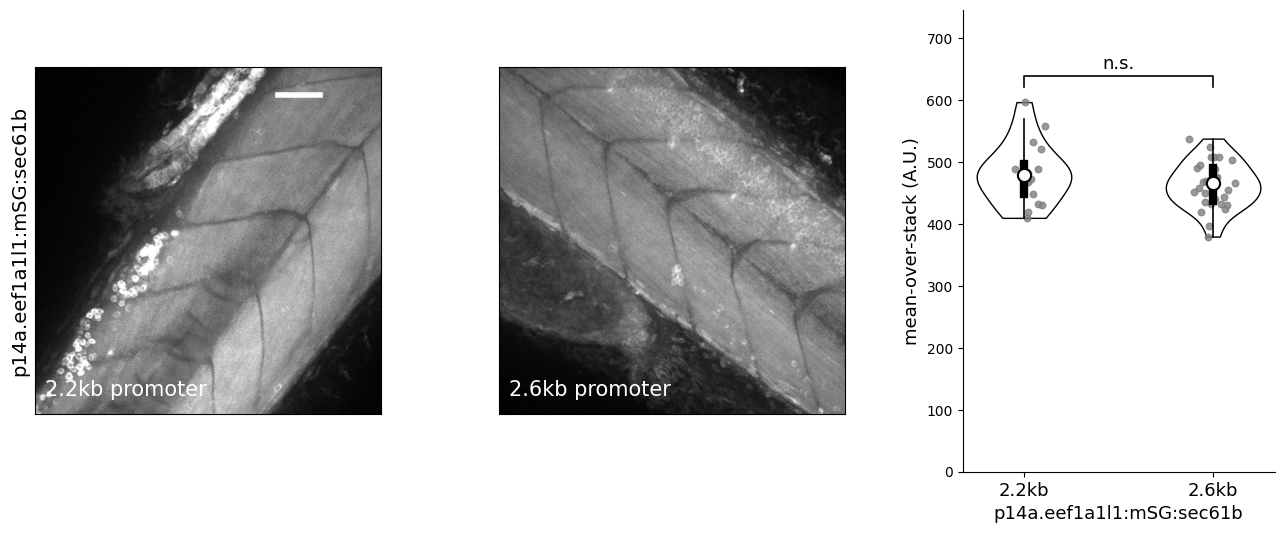

2.2kb (n=17) vs 2.6kb (n=30): mean 482 vs 464 A.U., Mann-Whitney n.s.


In [10]:
# Publication figure: labeled grayscale panels + violin (matches prior layout).
from scipy import stats

CONSTRUCT_TITLE = 'p14a.eef1a1l1:mSG:sec61b'
LABELS = {'14a-ef1a': '2.2kb', '14a-ef1a-extra': '2.6kb'}
order = ['14a-ef1a', '14a-ef1a-extra']   # left = 2.2kb, right = 2.6kb

# Representative (median-brightness) fish per construct, shared display scale.
reps = {}
for n in order:
    df = RESULTS[n]['df'].sort_values(PRIMARY)
    reps[n] = RESULTS[n]['mips'][df.iloc[len(df) // 2]['fish']]
vmax = np.percentile(np.concatenate([m.ravel() for m in reps.values()]), 99.5)
sb_px = int(50 / PIXEL_UM)   # 50 um scale bar

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.9], wspace=0.35)

for i, n in enumerate(order):
    ax = fig.add_subplot(gs[0, i])
    m = reps[n]
    ax.set_facecolor('black')
    ax.imshow(m, vmin=0, vmax=vmax, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.03, 0.04, f'{LABELS[n]} promoter', transform=ax.transAxes,
            color='white', fontsize=15, va='bottom', ha='left')
    if i == 0:
        ax.set_ylabel(CONSTRUCT_TITLE, fontsize=14)
        x0 = m.shape[1] * 0.70
        ax.plot([x0, x0 + sb_px], [m.shape[0] * 0.08] * 2, 'w-', lw=4)

# Violin panel
axv = fig.add_subplot(gs[0, 2])
data = [RESULTS[n]['df'][PRIMARY].values for n in order]
parts = axv.violinplot(data, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('white'); pc.set_edgecolor('black'); pc.set_alpha(1.0); pc.set_linewidth(1.0)
np.random.seed(0)
for i, g in enumerate(data):
    axv.scatter(np.random.normal(i + 1, 0.05, len(g)), g, s=22, color='gray', alpha=0.8, zorder=2)
    q1, med, q3 = np.percentile(g, [25, 50, 75])
    iqr = q3 - q1
    lo, hi = max(g.min(), q1 - 1.5 * iqr), min(g.max(), q3 + 1.5 * iqr)
    axv.plot([i + 1, i + 1], [lo, hi], color='black', lw=1.2, zorder=3)        # whiskers
    axv.plot([i + 1, i + 1], [q1, q3], color='black', lw=6, zorder=3)          # IQR box
    axv.scatter([i + 1], [med], s=90, facecolor='white', edgecolor='black', linewidth=1.5, zorder=4)  # median

_, p = stats.mannwhitneyu(data[0], data[1])
sig = 'n.s.' if p >= 0.05 else (f'p = {p:.3f}' if p >= 1e-3 else f'p = {p:.1e}')
ytop = max(g.max() for g in data)
axv.plot([1, 1, 2, 2], [ytop * 1.04, ytop * 1.07, ytop * 1.07, ytop * 1.04], color='black', lw=1.2)
axv.text(1.5, ytop * 1.08, sig, ha='center', va='bottom', fontsize=13)
axv.set_xticks([1, 2]); axv.set_xticklabels([LABELS[n] for n in order], fontsize=13)
axv.set_ylabel(PRIMARY_LABEL, fontsize=13)
axv.set_xlabel(CONSTRUCT_TITLE, fontsize=13)
axv.set_ylim(0, max(g.max() for g in data) * 1.25)
axv.spines[['top', 'right']].set_visible(False)

plt.savefig(FIGURES_DIR / 'publication_figure.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'publication_figure.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"2.2kb (n={len(data[0])}) vs 2.6kb (n={len(data[1])}): "
      f"mean {data[0].mean():.0f} vs {data[1].mean():.0f} A.U., Mann-Whitney {sig}")